# Please install the following python libraries
- python3: https://www.python.org/
- numpy: https://numpy.org/install/
- tqdm: https://github.com/tqdm/tqdm#installation
- matplotlib: https://matplotlib.org/stable/users/installing/index.html
- scipy: https://scipy.org/install/
- gymnasium: https://github.com/Farama-Foundation/Gymnasium (**New package to install**)
    - To install the base Gymnasium library, use **pip install gymnasium**

If you encounter the error: "IProgress not found. Please update jupyter & ipywidgets"
    
Please install the ipywidgets as follows:

    with pip, do
    - pip install ipywidgets
    
    with conda, do
    - conda install -c conda-forge ipywidgets
    
Restart your notebook 

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import random
import gymnasium as gym

from typing import Optional, Tuple
from enum import IntEnum

from gymnasium.utils.env_checker import check_env

from tqdm.auto import tqdm

In [ ]:
# Implement Simple MDP environment for extra credit

class Actions(IntEnum):
    LEFT = 0
    RIGHT = 1

class States(IntEnum):
    s = 0

class SimpleEnv(gym.Env):

    def __init__(self, return_prob: float = 0.9):
        self._state = -1

        self.observation_space = gym.spaces.Discrete(len(States))
        self.action_space = gym.spaces.Discrete(len(Actions))

        self._return_prob = return_prob

    def _get_obs(self):
        return self._state
    
    def _get_info(self):
        return {"state": self._state}
    
    def reset(self, seed: Optional[int] = None, options: Optional[dict] = None):
        super().reset(seed=seed)

        self._state = States.s

        obs = self._get_obs()
        info = self._get_info()

        return obs, info
    
    def step(self, action):
                
        if action == Actions.RIGHT:
            terminated = True
            reward = 0

        elif action == Actions.LEFT:
            if self.np_random.random() <= self._return_prob:
                terminated = False
                reward = 0
                self._state = self._state

            else:
                terminated = True
                reward = 1
        
        obs = self._get_obs()
        info = self._get_info()
        truncated = False

        return obs, reward, terminated, truncated, info


gym.register(
    id="SimpleEnv-v0",
    entry_point=SimpleEnv,
    max_episode_steps=300,  # Prevent infinite episodes
)       

In [ ]:
# Implement policy for simple environment

class SimplePolicy():

    def __init__(self,info):
        self.info = info
        self.actions = list(info.keys())
        self.probs = list(info.values())

    def choose_action(self,env):
        return env.np_random.choice(self.actions,p=self.probs)

In [ ]:
# Function to roll out trajectories for simple policies

def generate_trajectory(env, policy: SimplePolicy, max_steps=1000):
    T = []

    s,_ = env.reset()
    for i in range(max_steps):
        a = policy.choose_action(env)
        next_s,reward,terminated,truncated,_ = env.step(a) 
        done = terminated or truncated

        T.append((s,a,next_s,reward,done))
        s = next_s

        if done:
            break

    return T

In [ ]:
# Every visit MC eval

def run_MC_eval_every_visit(env, policy: SimplePolicy, gamma, episodes=10):
    Returns = {s:[] for s in States}
    for i in tqdm(range(episodes)):
        T = generate_trajectory(env,policy)

        G = 0
        for s,a,next_s,r,done in reversed(T):
            G = r + gamma*G
            Returns[s].append(G)

    V = {s:np.mean(Returns[s]) for s in States}
    return V

In [ ]:
# Every visit off-policy MC eval

def run_MC_eval_every_visit_off_policy(env, sample_policy: SimplePolicy, target_policy: SimplePolicy, gamma, episodes=10):
    V = {s:[0] for s in States}
    C = {s:0 for s in States}

    for i in tqdm(range(episodes)):
        T = generate_trajectory(env,sample_policy)

        G = 0
        W = 1
        for s,a,next_s,r,done in reversed(T):
            G = r + gamma*G
            C[s] = C[s]+W
            V[s].append(V[s][-1] + W/C[s]*(G-V[s][-1]))

            W = W*target_policy.info[a]/sample_policy.info[s]

    return V

In [ ]:
# Environment Testing

env = gym.make("SimpleEnv-v0")

try:
    check_env(env.unwrapped)
    print("Environment passes all checks!")
except Exception as e:
    print(f"Environment has issues: {e}")


policy_b  = SimplePolicy({Actions.RIGHT: 0.5, Actions.LEFT: 0.5})
policy_pi = SimplePolicy({Actions.RIGHT: 0.0, Actions.LEFT: 1.0})
init_s,init_info = env.reset()
print(f"initial state: {init_s}")

print(f"RIGHT: {env.step(Actions.RIGHT)}")
print(f"LEFT: {env.step(Actions.LEFT)}")

policy_pi.choose_action(env)

T = generate_trajectory(env,policy_b)
print(T)

Environment passes all checks!
initial state: 0
RIGHT: (<States.s: 0>, 0, True, False, {'state': <States.s: 0>})
LEFT: (<States.s: 0>, 0, False, False, {'state': <States.s: 0>})
[(<States.s: 0>, np.int64(1), <States.s: 0>, 0, True)]


  0%|          | 0/1000000 [00:00<?, ?it/s]

100%|██████████| 1000000/1000000 [00:42<00:00, 23721.61it/s]


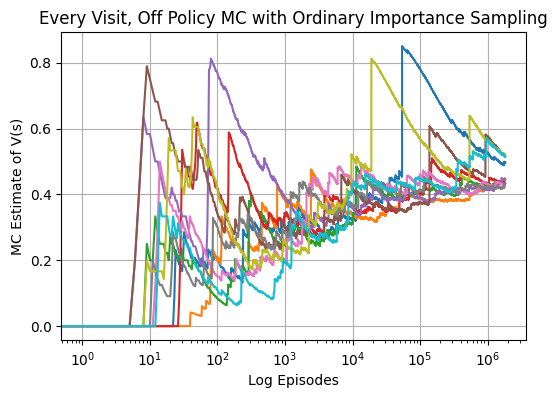

In [ ]:
# Generating Figure for infinite variance

policy_b  = SimplePolicy({Actions.RIGHT: 0.5, Actions.LEFT: 0.5})
policy_pi = SimplePolicy({Actions.RIGHT: 0.0, Actions.LEFT: 1.0})

env = gym.make("SimpleEnv-v0")

max_episodes = 1000000
runs = 10


fig, ax = plt.subplots(figsize=(6, 4))

for i in range(runs):
    V = run_MC_eval_every_visit_off_policy(env,policy_b,policy_pi,1,episodes=max_episodes)
    ax.semilogx(V[States.s])
    
ax.set_ylabel("MC Estimate of V(s)")
ax.set_xlabel("Log Episodes")
ax.set_title("Every Visit, Off Policy MC with Ordinary Importance Sampling")
ax.grid(True)



# Q2: Backjack 

Please note, since there is no scaffolding code for this question. Please make sure your implementation is well-tested and the comments are clear to understand. 

In [280]:
# test code for using the "Backjack" implementation from OpenAI
env = gym.make("Blackjack-v1")
env.reset()

# iteracting with the environment for 10 time steps using a random policy
for t in range(10): 
    # sample an random action
    action = env.action_space.sample()
    
    # interact with the envrionment
    next_s, reward, done, info, _ = env.step(action)
    
    # print info
    print(f"t = {t}, next_state = {next_s}, reward = {reward}, done = {done}")
    
    # check termination
    if done:
        env.reset()

t = 0, next_state = (27, 10, 0), reward = -1.0, done = True
t = 1, next_state = (21, 3, 0), reward = 0.0, done = False
t = 2, next_state = (27, 3, 0), reward = -1.0, done = True
t = 3, next_state = (26, 2, 0), reward = -1.0, done = True
t = 4, next_state = (18, 10, 0), reward = 0.0, done = False
t = 5, next_state = (24, 10, 0), reward = -1.0, done = True
t = 6, next_state = (24, 3, 0), reward = -1.0, done = True
t = 7, next_state = (20, 2, 0), reward = 1.0, done = True
t = 8, next_state = (17, 10, 0), reward = -1.0, done = True
t = 9, next_state = (10, 3, 0), reward = 0.0, done = False


In [ ]:
# Policy object

class Policy():

    def __init__(self,info,generator):
        # self.info = {s:{a:p for prob p for action a} for s in states}
        self.info = info
        self.generator = generator

    def choose_action(self,state):
        return self.generator.choice(list(self.info[state].keys()),p=list(self.info[state].values()))

In [ ]:
# Generate trajectory for full policy

def generate_trajectory(env: gym.Env, policy: Policy, max_steps=1000):
    T = []

    s,_ = env.reset()
    for _ in range(max_steps):
        a = policy.choose_action(s)
        next_s,reward,terminated,truncated,_ = env.step(a) 
        done = terminated or truncated

        T.append((s,a,next_s,reward,done))
        s = next_s

        if done:
            break

    return T

## (a): Implement first-visit Monte-Carlo policy evaluation (See pseudocode in 5.1). 

Please read Example 5.1 and reproduce Figure 1. The policy to be evaluated is the "sticks only on 20 or 21". Please only reproduce the plots after 500, 000 episodes (Usable ace and No usable ace). 

In [477]:
""" CODE HERE YOUR IMPLEMENTATION for Q2-(a) """
def run_MC_eval_first_visit(env: gym.Env, states, policy: Policy, gamma, episodes=10):
    Returns = {s:[] for s in states}
    for i in tqdm(range(episodes)):
        T = generate_trajectory(env,policy)

        G = 0
        for i,transition in enumerate(reversed(T)):
            s,a,next_s,r,done = transition
            G = r + gamma*G
            if s not in [t[0] for t in T[0:len(T)-1-i]]:
                Returns[s].append(G)

    V = {s:np.mean(Returns[s]) for s in states}
    return V

In [ ]:
# Plotting function

def plot_values(values, title):

    y_labels = list(np.linspace(start=12, stop=21, num=10, dtype=int))
    x_labels = list(np.linspace(start=1, stop=10, num=10, dtype=int))

    fig, ax = plt.subplots()
    im = ax.imshow(values, cmap="YlGn")

    # Show all ticks and label them with the respective list entries
    ax.set_xticks(np.arange(len(x_labels)), labels=x_labels)
    ax.set_yticks(np.arange(len(y_labels)), labels=y_labels)

    # Rotate the tick labels and set their alignment.
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
             rotation_mode="anchor")

    fig.colorbar(im,label="State Value")
            

    ax.set_title(title)
    ax.set_ylabel("Player Sum")
    ax.set_xlabel("Dealer Showing")
    fig.tight_layout()
    plt.show()

In [ ]:
# Test 1

env = gym.make("Blackjack-v1")
print(env.observation_space)

blackjack_states = [(i,j,k) for i in range(32) for j in range(11) for k in range(2)]

policy_info = {s: {0: 1 if s[0] in [20,21] else 0, 1: 0 if s[0] in [20,21] else 1} for s in blackjack_states}
policy = Policy(policy_info,env.np_random)
# print(policy_info)

# a = policy.choose_action((20,0,0))
# print(a)

# count_len_1 = 0
# for i in tqdm(range(1000)):
#     T = generate_trajectory(env,policy)
#     if len(T) > 1:
#         count_len_1 += 1

# print(count_len_1)

# V = run_MC_eval_every_visit(env,blackjack_states,policy,1,episodes=500000)
V = run_MC_eval_first_visit(env,blackjack_states,policy,1,episodes=500000)

# print(V)

Tuple(Discrete(32), Discrete(11), Discrete(2))


100%|██████████| 500000/500000 [01:02<00:00, 7937.35it/s] 
c:\workspace\cs5180rl-main\cs5180rl\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\workspace\cs5180rl-main\cs5180rl\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


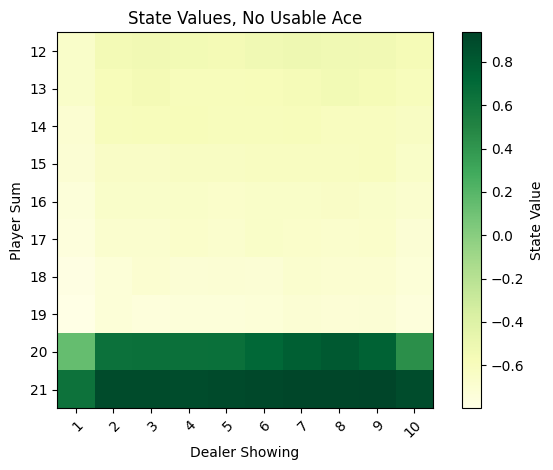

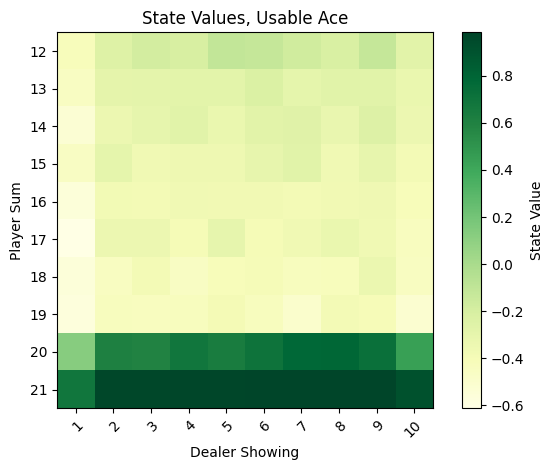

In [ ]:
# Figure 1

V_grid0 = np.zeros((10,10))
for i,player in enumerate(range(12,22)):
    for j,dealer in enumerate(range(1,11)):
        V_grid0[i][j] = V[(player,dealer,0)]

plot_values(V_grid0,"State Values, No Usable Ace")

V_grid1 = np.zeros((10,10))
for i,player in enumerate(range(12,22)):
    for j,dealer in enumerate(range(1,11)):
        V_grid1[i][j] = V[(player,dealer,1)]

plot_values(V_grid1,"State Values, Usable Ace")

## (b): Implement first-visit Monte-Carlo control with exploring starts (Monte-Carlo ES in 5.3). 

Please read the Example 5.1 and reproduce the Figure 5.2

In [ ]:
# Trajectory rollouts with specified starting action

def generate_trajectory_started(env: gym.Env, policy: Policy, a0, max_steps=1000):
    T = []

    s,_ = env.reset()
    started = False
    for _ in range(max_steps):
        
        if started:
            a = policy.choose_action(s)
        else:
            a = a0
            started = True

        next_s,reward,terminated,truncated,_ = env.step(a) 
        done = terminated or truncated

        T.append((s,a,next_s,reward,done))
        s = next_s

        if done:
            break

    return T

In [483]:
""" CODE HERE YOUR IMPLEMENTATION for Q2-(b) """
def run_MC_eval_first_visit_es(env: gym.Env, states, policy: Policy, gamma, episodes=10):
    Returns = {s:[] for s in states}
    for i in tqdm(range(episodes)):
        a0 = env.action_space.sample()
        T = generate_trajectory_started(env,policy,a0)

        G = 0
        for i,transition in enumerate(reversed(T)):
            s,a,next_s,r,done = transition
            G = r + gamma*G
            if s not in [t[0] for t in T[0:len(T)-1-i]]:
                Returns[s].append(G)

    V = {s:np.mean(Returns[s]) for s in states}
    return V

In [ ]:
# Test 2 - ES

env = gym.make("Blackjack-v1")
print(env.observation_space)

blackjack_states = [(i,j,k) for i in range(32) for j in range(11) for k in range(2)]

policy_info = {s: {0: 1 if s[0] in [20,21] else 0, 1: 0 if s[0] in [20,21] else 1} for s in blackjack_states}
policy = Policy(policy_info,env.np_random)


V = run_MC_eval_first_visit_es(env,blackjack_states,policy,1,episodes=500000)

Tuple(Discrete(32), Discrete(11), Discrete(2))


100%|██████████| 500000/500000 [00:39<00:00, 12564.11it/s]
c:\workspace\cs5180rl-main\cs5180rl\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\workspace\cs5180rl-main\cs5180rl\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


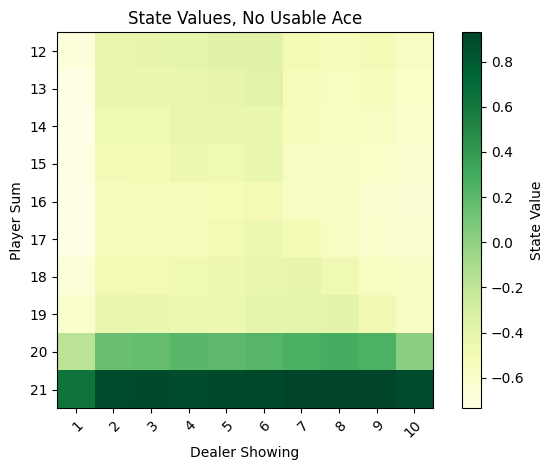

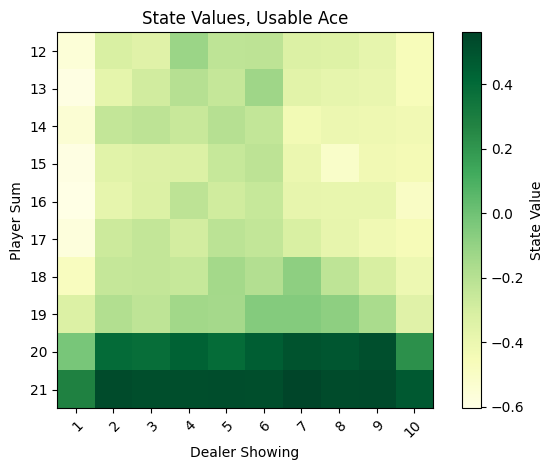

In [ ]:
# Figure 2 - ES

V_grid0 = np.zeros((10,10))
for i,player in enumerate(range(12,22)):
    for j,dealer in enumerate(range(1,11)):
        V_grid0[i][j] = V[(player,dealer,0)]

plot_values(V_grid0,"State Values, No Usable Ace")

V_grid1 = np.zeros((10,10))
for i,player in enumerate(range(12,22)):
    for j,dealer in enumerate(range(1,11)):
        V_grid1[i][j] = V[(player,dealer,1)]

plot_values(V_grid1,"State Values, Usable Ace")

# Q3: Four Rooms, re-visited

In [4]:
"""DO NOT CHANGE"""
class FourRooms(object):
    def __init__(self):
        # define the four room as a 2-D array for easy state space reference and visualization
        # 0 represents an empty cell; 1 represents a wall cell
        self.four_room_space = np.array([[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                                         [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                                         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                                         [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                                         [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                                         [1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0],
                                         [0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1],
                                         [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                                         [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                                         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                                         [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0]])

        # find the positions for all empty cells
        # note that: the origin for a 2-D numpy array is located at top-left while the origin for the FourRooms is at
        # the bottom-left. The following codes performs the re-projection.
        empty_cells = np.where(self.four_room_space == 0.0)
        self.state_space = [[col, 10 - row] for row, col in zip(empty_cells[0], empty_cells[1])]

        # define the action space
        self.action_space = {'LEFT': np.array([-1, 0]),
                             'RIGHT': np.array([1, 0]),
                             'DOWN': np.array([0, -1]),
                             'UP': np.array([0, 1])}

        # define the start state
        self.start_state = [0, 0]

        # define the goal state
        self.goal_state = [10, 10]

        # maximal time steps
        self.max_time_steps = 459

        # track the time step
        self.t = 0

    def reset(self):
        """
        Reset the agent's state to the start state [0, 0]
        Return both the start state and reward
        """
        # reset the agent state to be [0, 0]
        state = self.start_state
        # reset the reward to be 0
        reward = 0
        # reset the termination flag
        done = False
        # reset the time step tracker
        self.t = 0
        return state, reward, done

    def step(self, state, act):
        """
        Args:
            state: a list variable containing x, y integer coordinates. (i.e., [1, 1]).
            act: a string variable (i.e., "UP"). All feasible values are ["UP", "DOWN", "LEFT", "RIGHT"].
        Output args:
            next_state: a list variable containing x, y integer coordinates (i.e., [1, 1])
            reward: an integer. it can be either 0 or 1.
        """
        # Increase the time step
        self.t += 1

        # With probability 0.8, the agent takes the correct direction.
        # With probability 0.2, the agent takes one of the two perpendicular actions.
        # For example, if the correct action is "LEFT", then
        #     - With probability 0.8, the agent takes action "LEFT";
        #     - With probability 0.1, the agent takes action "UP";
        #     - With probability 0.1, the agent takes action "DOWN".
        if np.random.uniform() < 0.2:
            if act == "LEFT" or act == "RIGHT":
                act = np.random.choice(["UP", "DOWN"], 1)[0]
            else:
                act = np.random.choice(["RIGHT", "LEFT"], 1)[0]

        # Compute the next state
        next_state = self.take_action(state, act)

        # Compute the reward
        reward = 1.0 if next_state == [10, 10] else 0.0

        # Check the termination
        # If the agent reaches the goal, reward = 1, done = True
        # If the time steps reaches the maximal number, reward = 0, done = True.
        if next_state == [10, 10] or self.t == self.max_time_steps:
            done = True
        else:
            done = False

        return next_state, reward, done

    def take_action(self, state, act):
        """
        Input args:
            state (list): a list variable containing x, y integer coordinates. (i.e., [1, 1]).
            act (string): a string variable (i.e., "UP"). All feasible values are ["UP", "DOWN", "LEFT", "RIGHT"].
        Output args:
            next_state (list): a list variable containing x, y integer coordinates (i.e., [1, 1])
        """
        state = np.array(state)
        next_state = state + self.action_space[act]
        return next_state.tolist() if next_state.tolist() in self.state_space else state.tolist()

## (a): Implement first-visit Monte-Carlo control with a epsilon-greedy policy

In [5]:
""" CODE HERE YOUR IMPLEMENTATION for Q3-(a) """
# Implementation of the one-policy first-vist Monte-Carlo control (for ε-soft policies) here.
# To debug your code, you can use run_num = 5 and episode_num = 1e3
# To report the finial results, please use run_num = 10 and episode_num = 1e4

class Policy():

    def __init__(self,info,generator):
        # self.info = {s:{a:p for prob p for action a} for s in states}
        self.info = info
        self.generator = generator

    def choose_action(self,state):
        return self.generator.choice(list(self.info[state].keys()),p=list(self.info[state].values()))
    
    def update_prob(self,state,action,prob):
        self.info[state][action] = prob
    
def generate_trajectory(env: gym.Env, policy: Policy, max_steps=1000):
    T = []

    s,_,_ = env.reset()
    for _ in range(max_steps):
        a = policy.choose_action(tuple(s))
        next_s,reward,done = env.step(s,a)

        T.append((tuple(s),a,tuple(next_s),reward,done))
        s = next_s

        if done:
            break

    return T

In [ ]:
# Visualization

def plot_policy(values,policy,title):
    # values = np.flip(values,axis=0)
    # policy = np.flip(policy,axis=0)

    x_labels = list(np.linspace(start=0, stop=10, num=11, dtype=int))    
    y_labels = list(np.linspace(start=0, stop=10, num=11, dtype=int))
    

    fig, ax = plt.subplots()
    im = ax.imshow(values, cmap="YlGn", origin="lower")
    

    # Show all ticks and label them with the respective list entries
    ax.set_xticks(np.arange(len(x_labels))-0.5, labels=x_labels)
    ax.set_yticks(np.arange(len(y_labels))-0.5, labels=y_labels)

    for x in x_labels:
        for y in y_labels:
            a = policy[y][x]
            dx = -0.5 if a=="LEFT" else 0.5 if a=="RIGHT" else 0
            dy = -0.5 if a=="DOWN" else 0.5 if a=="UP" else 0
            ax.quiver([x],[y],[dx],[dy],pivot='middle',scale=1,scale_units='xy')

    # Rotate the tick labels and set their alignment.
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
             rotation_mode="anchor")

    fig.colorbar(im,label="State Value")
            

    ax.set_title(title)
    ax.set_ylabel("y")
    ax.set_xlabel("x")
    fig.tight_layout()
    ax.grid(True)
    plt.show()

In [ ]:
# MC Control First Visist Epsilon Soft

def run_MC_control_e_first_visit(env: gym.Env, states, actions, starter_policy: Policy, epsilon, gamma, episodes=10):
    Returns = {s:{a: [] for a in actions} for s in states}
    Q = {s: {a:0 for a in actions} for s in states}
    policy = starter_policy
    all_discounted_rewards = []
    episode_lengths = []

    for i in tqdm(range(episodes),desc="MC",leave=False,position=1):
        T = generate_trajectory(env,policy)

        G = 0
        for j,transition in enumerate(reversed(T)):
            s,a,next_s,r,done = transition
            G = r + gamma*G
            
            # print(s,a)
            # print([(t[0],t[1]) for t in T[0:len(T)-1-j]])
            if (s,a) not in [(t[0],t[1]) for t in T[0:len(T)-1-j]]:
                Returns[s][a].append(G)
                Q[s][a] = np.mean(Returns[s][a]) if len(Returns[s][a]) > 0 else 0
                astarlist = [act for act in actions if Q[s][act] == max(Q[s].values())]
                astar = random.choice(astarlist)
                # print(a)
                # print(astar)
                # print(G)

                for action in actions:
                    new_prob = 1 - epsilon + epsilon/len(actions) if action == astar else epsilon/len(actions)
                    # print(new_prob)
                    policy.update_prob(s,action,new_prob)

        episode_lengths.append(len(transition))
        all_discounted_rewards.append(G)

        
                     
    return Q, policy, episode_lengths, all_discounted_rewards

In [ ]:
# Test

env = FourRooms()
# print(env.state_space)
states = [tuple(s) for s in env.state_space]
actions = ["LEFT","RIGHT","DOWN","UP"]

policy_info = {s: {a: 1/len(actions) for a in actions} for s in states}
starter_policy = Policy(policy_info,np.random.default_rng(2025))
# print(policy_info)

# for i in range(10):
#     a = policy.choose_action((0,1))
#     print(a)

runs = 10
episodes = 1000

# Qs = []
# Ps = []
# Ls = []
Rs01 = []
Rs001 = []
Rs0 = []
Ls01 = []
Ls001 = []
Ls0 = []

for _ in tqdm(range(runs),desc="Runs",position=0):  
    Q,pstar,episode_lengths,rewards = run_MC_control_e_first_visit(env,states,actions,starter_policy,0.1,1,episodes=episodes)
    # Qs.append(Q)
    # Ps.append(pstar)
    # Ls.append(episode_lengths)
    Rs01.append(rewards)
    Ls01.append(episode_lengths)

    Q,pstar,episode_lengths,rewards = run_MC_control_e_first_visit(env,states,actions,starter_policy,0.01,1,episodes=episodes)
    Rs001.append(rewards)
    Ls001.append(episode_lengths)

    Q,pstar,episode_lengths,rewards = run_MC_control_e_first_visit(env,states,actions,starter_policy,0,1,episodes=episodes)
    Rs0.append(rewards)
    Ls0.append(episode_lengths)
# print(V)

Runs:   0%|          | 0/10 [00:00<?, ?it/s]

MC:   0%|          | 0/1000 [00:00<?, ?it/s]

MC:   0%|          | 0/1000 [00:00<?, ?it/s]

MC:   0%|          | 0/1000 [00:00<?, ?it/s]

MC:   0%|          | 0/1000 [00:00<?, ?it/s]

...

MC:   0%|          | 0/1000 [00:00<?, ?it/s]

MC:   0%|          | 0/1000 [00:00<?, ?it/s]

MC:   0%|          | 0/1000 [00:00<?, ?it/s]

MC:   0%|          | 0/1000 [00:00<?, ?it/s]

MC:   0%|          | 0/1000 [00:00<?, ?it/s]

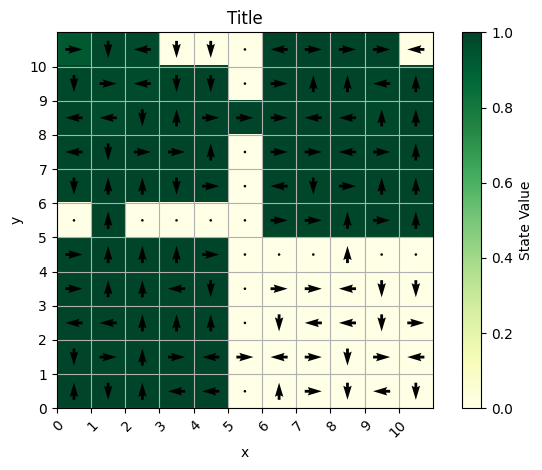

In [ ]:
# Visualize for debugging

# print(policy_info)

# for s,a in zip(pstar.info.keys(),pstar.info.values()):
#     print(f"{s} | {a}")

Pgrid = [["" for i in range(11)] for j in range(11)]
for x in range(11):
    for y in range(11):
        try:
            Pgrid[y][x] = max(pstar.info[(x,y)],key=pstar.info[(x,y)].get) 
        except:
            Pgrid[y][x] = ""

Vgrid = np.zeros((11,11))
for x in range(11):
    for y in range(11):
        try:
            Vgrid[y][x] = Q[(x,y)][Pgrid[y][x]]
        except:
            Vgrid[y][x] = 0





plot_policy(Vgrid,Pgrid,"Title")

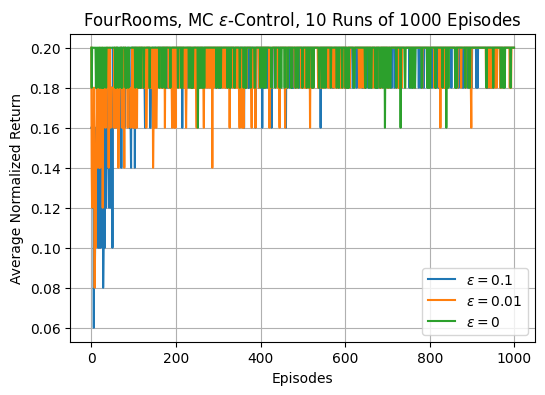

In [ ]:
# Figure 3

# print(pstar.info)

fig, ax = plt.subplots(figsize=(6, 4))

# ax.plot(rewards)
# ax.plot(np.mean(Rs01,axis=0),label="$\\epsilon=0.1$")
# ax.plot(np.mean(Rs001,axis=0),label="$\\epsilon=0.01$")
# ax.plot(np.mean(Rs0,axis=0),label="$\\epsilon=0$")

ax.plot(np.mean(np.divide(Rs01,Ls01),axis=0),label="$\\epsilon=0.1$")
ax.plot(np.mean(np.divide(Rs001,Ls001),axis=0),label="$\\epsilon=0.01$")
ax.plot(np.mean(np.divide(Rs0,Ls0),axis=0),label="$\\epsilon=0$")
    
# ax.set_ylabel("Average Discounted Rewards")
ax.set_ylabel("Average Normalized Return")
ax.set_xlabel("Episodes")
ax.set_title("FourRooms, MC $\\epsilon$-Control, 10 Runs of 1000 Episodes")
ax.grid(True)
ax.legend()

## Q5: Racktrack

Please note, we provde you with the implementation of the two Racetrack domains in the Figure 5.5.

In [8]:
# Define the Racetrack domain 1
racetrack_v1_arr = np.array([
            [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3],
            [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3],
            [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3],
            [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3],
            [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3],
            [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3],
            [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1],
            [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1]])

racetrack_v2_arr = np.array([
            [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3],
            [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3],
            [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3],
            [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3],
            [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3],
            [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3],
            [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3],
            [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3],
            [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3],
            [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1],
            [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
            [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1],
            [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
            [1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1]])

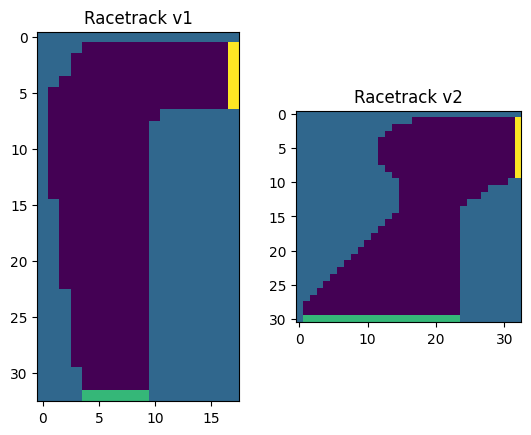

In [9]:
fig, arr = plt.subplots(1, 2)
arr[0].set_title("Racetrack v1")
arr[0].imshow(racetrack_v1_arr)
arr[1].set_title("Racetrack v2")
arr[1].imshow(racetrack_v2_arr)
plt.show()

In [10]:
"""Implementation of the Racetrack environment. Do not change"""
class Racetrack(object):
    def __init__(self, version):
        # Load the pre-defined the domain having the following representation
        #   - 1: track cell
        #   - 0: empty cell
        #   - 2: empty cell on the start line
        #   - 3: empty cell on the finish line
        if version == "v1":
            self.domain_arr = racetrack_v1_arr.copy()
        else:
            self.domain_arr = racetrack_v2_arr.copy()

        # domain size
        self.height, self.width = self.domain_arr.shape

        # State space consists of:
        # Agent location
        self.empty_cell_locs = self.render_cell_locations(val=0.0)
        self.track_cell_locs = self.render_cell_locations(val=1.0)
        self.start_cell_locs = self.render_cell_locations(val=2.0)
        self.finish_cell_locs = self.render_cell_locations(val=3.0)

        # Action space
        self.action_space = [[-1, -1], [-1, 0], [-1, 1],
                             [0, -1], [0, 0], [0, 1],
                             [1, -1], [1, 0], [1, 1]]

        # construct the state space
        self.state_space = []
        for loc in self.start_cell_locs + self.empty_cell_locs + self.finish_cell_locs:
            for i in range(5):
                for j in range(5):
                    self.state_space.append(loc + [i, j])

        # track the agent's location
        self.state = None
        self.action = None
        self.t = None

    def reset(self):
        # randomly select one cell from the start line
        start_loc = random.sample(self.start_cell_locs, 1)[0]
        # reset the velocity to be zero for both x and y directions
        start_vel = [0, 0]
        # the state is a combination of location and velocity
        # for example: [loc_x, loc_y, vel_x, vel_y]
        state = start_loc + start_vel
        # reward
        reward = None
        # done
        done = False
        # track agent's location
        self.state = tuple(state)
        self.t = 0
        return state, reward, done

    def step(self, state, action):
        """
        Args:
            state (list): a list variable consists of agent's location + agent's current velocity. e.g., [x, y, v_x, v_y]
            action (list): a list variable consists of agent's velocity increments. e.g., [increments_v_x, increments_v_y]
        """
        # reward is -1 for every time step until the agent passes the finish line
        reward = -1
        self.t += 1
        
        # with the probability = 0.1, set action = [0, 0]
        if np.random.random() < 0.1:
            action = [0, 0]

        # update the velocity components
        # note that, both velocity is discrete and constraint within [0, 4]
        next_vel_x = np.clip(state[2] + action[0], a_min=0, a_max=4)
        next_vel_y = np.clip(state[3] + action[1], a_min=0, a_max=4)
        next_state_vel = [next_vel_x, next_vel_y]

        # only the cells on the start line can have both 0 velocities
        if next_state_vel == [0, 0]:
            if state not in self.start_cell_locs:
                # non-zero for velocities
                if state[2] == 0 and state[3] != 0:
                    next_state_vel = [0, 1]
                if state[2] != 0 and state[3] == 0:
                    next_state_vel = [1, 0]
                if state[2] != 0 and state[3] != 0:
                    non_zero_idx = random.sample([0, 1], 1)[0]
                    next_state_vel[non_zero_idx] = 1

        # update the next state location based on the updated velocities
        next_state_loc = [np.clip(state[0] + next_state_vel[0], a_min=0, a_max=self.width-1),
                          np.clip(state[1] + next_state_vel[1], a_min=0, a_max=self.height-1)]

        # check whether the agent hits the track
        if next_state_loc in self.track_cell_locs:
            # move back to the start line
            next_state_loc = random.sample(self.start_cell_locs, 1)[0]
            # reduce velocity to be 0s
            next_state_vel = [0, 0]
            # episode continue
            done = False
            # next state
            next_state = next_state_loc + next_state_vel
            return next_state, reward, done

        # check whether the agent pass the finish line
        if next_state_loc in self.finish_cell_locs:
            next_state = next_state_loc + next_state_vel
            done = True
            return next_state, 0, done

        # otherwise combine the next state
        next_state = next_state_loc + next_state_vel
        # termination
        done = False

        # track the agent's state
        self.state = tuple(next_state)
        self.action = action
        return next_state, reward, done

    def render_cell_locations(self, val):
        row_loc_indices, col_loc_indices = np.where(self.domain_arr == val)
        cell_locations = [[c, (self.height-1) - r] for r, c in zip(row_loc_indices, col_loc_indices)]
        return cell_locations

    def render(self):
        plt.clf()
        plt.title(f"s = {self.state}, a = {self.action}")
        plot_arr = self.domain_arr.copy()
        plot_arr[(self.height - 1) - self.state[1], self.state[0]] = 4
        plt.imshow(plot_arr)
        plt.show(block=False)
        plt.pause(0.01)

## (a): Implement first-visit Monte-Carlo control with a epsilon-greedy policy (epsilon = 0.1)
    - Plot the learning curves for the two tracks.
    - Use running trials number = 10 and episodes number = 2000

In [ ]:
# Helper functions

""" CODE HERE YOUR IMPLEMENTATION for Q5-(a) """
# Implement here and use the plotting function above to plot the learning curve 

class Policy():

    def __init__(self,info,generator):
        # self.info = {s:{a:p for prob p for action a} for s in states}
        self.info = info
        self.generator = generator

    def choose_action(self,state):
        return self.generator.choice(list(self.info[state].keys()),p=list(self.info[state].values()))
    
    def update_prob(self,state,action,prob):
        self.info[state][action] = prob
    
def generate_trajectory(env: gym.Env, policy: Policy, max_steps=1000):
    T = []

    s,_,_ = env.reset()
    for _ in range(max_steps):
        a = policy.choose_action(tuple(s))
        next_s,reward,done = env.step(s,a)

        T.append((tuple(s),tuple(a),tuple(next_s),reward,done))
        s = next_s

        if done:
            break

    return T

In [ ]:
# MC Control epsilon soft first visit

def run_MC_control_e_first_visit(env: gym.Env, states, actions, starter_policy: Policy, epsilon, gamma, episodes=10):
    Returns = {s:{a: [] for a in actions} for s in states}
    Q = {s: {a:0 for a in actions} for s in states}
    policy = starter_policy
    all_discounted_rewards = []
    episode_lengths = []

    for i in tqdm(range(episodes),desc="MC",leave=False,position=1):
        T = generate_trajectory(env,policy)

        G = 0
        for j,transition in enumerate(reversed(T)):
            s,a,next_s,r,done = transition
            G = r + gamma*G
            
            # print(s,a)
            # print([(t[0],t[1]) for t in T[0:len(T)-1-j]])
            if (s,a) not in [(t[0],t[1]) for t in T[0:len(T)-1-j]]:
                Returns[s][a].append(G)
                Q[s][a] = np.mean(Returns[s][a]) if len(Returns[s][a]) > 0 else 0
                astarlist = [act for act in actions if Q[s][act] == max(Q[s].values())]
                astar = random.choice(astarlist)
                # print(a)
                # print(astar)
                # print(G)

                for action in actions:
                    new_prob = 1 - epsilon + epsilon/len(actions) if action == astar else epsilon/len(actions)
                    # print(new_prob)
                    policy.update_prob(s,action,new_prob)

        episode_lengths.append(len(transition))
        all_discounted_rewards.append(G)

        
                     
    return Q, policy, episode_lengths, all_discounted_rewards

In [ ]:
# Visualization

def visualize_trajectory(env, policy: Policy):
    state,reward,done = env.reset()
    plot_arr = env.domain_arr.copy()

    while not done:
        action = policy.choose_action(tuple(state))
        state,reward,done = env.step(state,action)

        plot_arr[(env.height - 1) - env.state[1], env.state[0]] = 4
        
        
    plt.title(f"Visualized Trajectory for Policy")
    plt.imshow(plot_arr)
    plt.show(block=False)
    plt.pause(0.01)




def plot_policy(values,policy,title):
    # values = np.flip(values,axis=0)
    # policy = np.flip(policy,axis=0)

    x_labels = list(np.linspace(start=0, stop=10, num=11, dtype=int))    
    y_labels = list(np.linspace(start=0, stop=10, num=11, dtype=int))
    

    fig, ax = plt.subplots()
    im = ax.imshow(values, cmap="YlGn", origin="lower")
    

    # Show all ticks and label them with the respective list entries
    ax.set_xticks(np.arange(len(x_labels))-0.5, labels=x_labels)
    ax.set_yticks(np.arange(len(y_labels))-0.5, labels=y_labels)

    for x in x_labels:
        for y in y_labels:
            a = policy[y][x]
            dx = -0.5 if a=="LEFT" else 0.5 if a=="RIGHT" else 0
            dy = -0.5 if a=="DOWN" else 0.5 if a=="UP" else 0
            ax.quiver([x],[y],[dx],[dy],pivot='middle',scale=1,scale_units='xy')

    # Rotate the tick labels and set their alignment.
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
             rotation_mode="anchor")

    fig.colorbar(im,label="State Value")
            

    ax.set_title(title)
    ax.set_ylabel("y")
    ax.set_xlabel("x")
    fig.tight_layout()
    ax.grid(True)
    plt.show()

In [ ]:
# Test 1 - V1 MCE

env1 = Racetrack("v1")
# env.reset()
# env.render()
# print(env.state_space)
states = [tuple(s) for s in env1.state_space]
actions = [tuple(a) for a in env1.action_space]
# print(states)

policy_info = {s: {a: 1/len(actions) for a in actions} for s in states}
starter_policy = Policy(policy_info,np.random.default_rng(2025))
# print(policy_info)

runs = 10
episodes = 1000


Rs1 = []

for _ in tqdm(range(runs),desc="Runs",position=0):
    Q,pstar1,episode_lengths,rewards = run_MC_control_e_first_visit(env1,states,actions,starter_policy,0.1,1,episodes=episodes)
    Rs1.append(rewards)
# env.render()

Runs:   0%|          | 0/10 [00:00<?, ?it/s]

MC:   0%|          | 0/1000 [00:00<?, ?it/s]

MC:   0%|          | 0/1000 [00:00<?, ?it/s]

MC:   0%|          | 0/1000 [00:00<?, ?it/s]

MC:   0%|          | 0/1000 [00:00<?, ?it/s]

...

MC:   0%|          | 0/1000 [00:00<?, ?it/s]

MC:   0%|          | 0/1000 [00:00<?, ?it/s]

MC:   0%|          | 0/1000 [00:00<?, ?it/s]

MC:   0%|          | 0/1000 [00:00<?, ?it/s]

MC:   0%|          | 0/1000 [00:00<?, ?it/s]

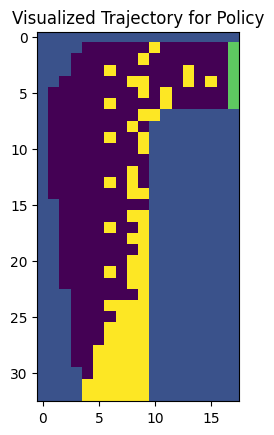

In [1087]:
visualize_trajectory(env1,pstar1)

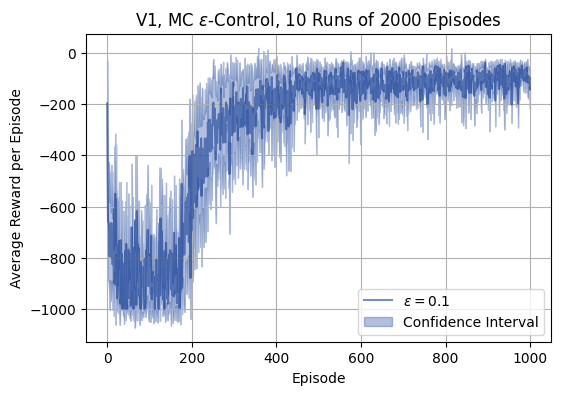

In [ ]:
# Figure 1 - V1 MCE

fig, ax = plt.subplots(figsize=(6, 4))

Rs1arr = np.array(Rs1)

color = "#05318F8B"

avg = np.mean(Rs1arr,axis=0)
err = 1.96 * Rs1arr.std(axis=0) / np.sqrt(Rs1arr.shape[0])

ax.plot(avg,label="$\\epsilon=0.1$",color=color)
ax.fill_between(range(avg.shape[0]),avg-err,avg+err,alpha=0.3,color=color,label="Confidence Interval")
    
ax.set_ylabel("Average Reward per Episode")
ax.set_xlabel("Episode")
ax.set_title("V1, MC $\\epsilon$-Control, 10 Runs of 2000 Episodes")
ax.grid(True)
ax.legend()

V2

In [ ]:
# Test 2 - V2 MCE

env2 = Racetrack("v2")
# env.reset()
# env.render()
# print(env.state_space)
states = [tuple(s) for s in env2.state_space]
actions = [tuple(a) for a in env2.action_space]
# print(states)

policy_info = {s: {a: 1/len(actions) for a in actions} for s in states}
starter_policy = Policy(policy_info,np.random.default_rng(2025))
# print(policy_info)

runs = 10
episodes = 2000


Rs2 = []

for _ in tqdm(range(runs),desc="Runs",position=0):
    Q,pstar2,episode_lengths,rewards = run_MC_control_e_first_visit(env2,states,actions,starter_policy,0.1,1,episodes=episodes)
    Rs2.append(rewards)
# env.render()



Runs:   0%|          | 0/10 [00:00<?, ?it/s]

MC:   0%|          | 0/2000 [00:00<?, ?it/s]

MC:   0%|          | 0/2000 [00:00<?, ?it/s]

MC:   0%|          | 0/2000 [00:00<?, ?it/s]

MC:   0%|          | 0/2000 [00:00<?, ?it/s]

...

MC:   0%|          | 0/2000 [00:00<?, ?it/s]

MC:   0%|          | 0/2000 [00:00<?, ?it/s]

MC:   0%|          | 0/2000 [00:00<?, ?it/s]

MC:   0%|          | 0/2000 [00:00<?, ?it/s]

MC:   0%|          | 0/2000 [00:00<?, ?it/s]

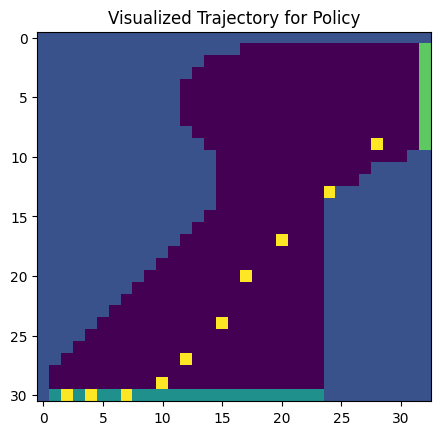

In [1064]:
visualize_trajectory(env2,pstar2)

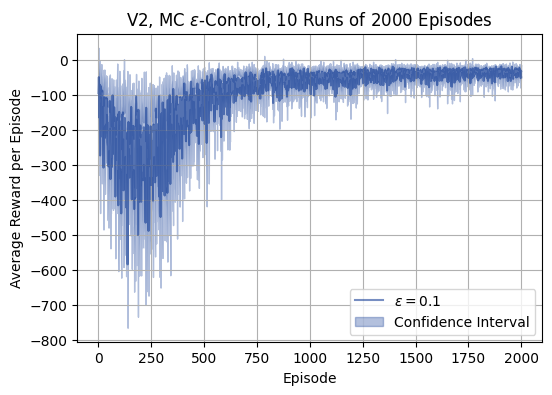

In [ ]:
# Figure 2 - V2 MCE

fig, ax = plt.subplots(figsize=(6, 4))

Rs2arr = np.array(Rs2)

color = "#05318F8B"

avg = np.mean(Rs2arr,axis=0)
err = 1.96 * Rs2arr.std(axis=0) / np.sqrt(Rs2arr.shape[0])

ax.plot(avg,label="$\\epsilon=0.1$",color=color)
ax.fill_between(range(avg.shape[0]),avg-err,avg+err,alpha=0.3,color=color,label="Confidence Interval")
    
ax.set_ylabel("Average Reward per Episode")
ax.set_xlabel("Episode")
ax.set_title("V2, MC $\\epsilon$-Control, 10 Runs of 2000 Episodes")
ax.grid(True)
ax.legend()

## (b): Implement off-policy Monte-Carlo control. Please specify what behavior policy you are using.
    - Plot the learning curves for the two tracks
    - Using running trials number = 10 and episodes number = 2000

In [14]:
from joblib import Parallel, delayed

In [ ]:
# MC Control off policy

""" CODE HERE YOUR IMPLEMENTATION for Q5-(b) """
# Implement here and use the plotting function above to plot the learning curve 
def run_MC_control_e_every_visit_off_policy(env: gym.Env, states, actions, starter_target_policy: Policy, starter_behavior_policy: Policy, epsilon, gamma, episodes=10):
    Q = {s: {a:0 for a in actions} for s in states}
    C = {s: {a:0 for a in actions} for s in states}
    target_policy = starter_target_policy
    behavior_policy = starter_behavior_policy
    all_discounted_rewards = []
    episode_lengths = []

    for i in tqdm(range(episodes),desc="MC",leave=False,position=1):
        T = generate_trajectory(env,behavior_policy)

        G = 0
        W = 1
        for j,transition in enumerate(reversed(T)):
            s,a,next_s,r,done = transition
            G = r + gamma*G
            C[s][a] = C[s][a] + W
            Q[s][a] = Q[s][a] + W/C[s][a]*(G-Q[s][a])
            astarlist = [act for act in actions if Q[s][act] == max(Q[s].values())]
            astar = random.choice(astarlist) # TODO: consider making this consistent

            
            for action in actions:
                # Behavior Policy Update
                new_behavior_prob = 1 - epsilon + epsilon/len(actions) if action == astar else epsilon/len(actions)
                behavior_policy.update_prob(s,action,new_behavior_prob)

                # Target Policy Update
                new_target_prob = 1 if action == astar else 0
                target_policy.update_prob(s,action,new_target_prob)

            if a[0] != target_policy.choose_action(s)[0] or a[1] != target_policy.choose_action(s)[1]:
                T_test = generate_trajectory(env,behavior_policy)
                G_test = 0
                for transition in reversed(T_test):
                    s,a,next_s,r,done = transition
                    G_test = r + gamma*G_test

                break

            W = 1/target_policy.info[s][a]*W

            
                

        episode_lengths.append(len(transition))
        all_discounted_rewards.append(G_test)

        
                     
    return Q, target_policy, behavior_policy, episode_lengths, all_discounted_rewards

In [ ]:
# Test 3 - V1 MC OP

# env3 = Racetrack("v1")
# env.reset()
# env.render()
# print(env.state_space)
states = [tuple(s) for s in env3.state_space]
actions = [tuple(a) for a in env3.action_space]
# print(states)


# policy_info = {s: {a: 1/len(actions) for a in actions} for s in states}
# starter_policy = Policy(policy_info,np.random.default_rng(seed))
# print(policy_info)

runs = 10
episodes = 2000

def do_one_run(seed):
    env3 = Racetrack("v1")
    states = [tuple(s) for s in env3.state_space]
    actions = [tuple(a) for a in env3.action_space]
    policy_info = {s: {a: 1/len(actions) for a in actions} for s in states}
    starter_policy = Policy(policy_info,np.random.default_rng(seed))
    Q,pstar3,bpolicy,episode_lengths,rewards = run_MC_control_e_every_visit_off_policy(env3,states,actions,starter_policy,starter_policy,0.1,1,episodes=episodes)

    return pstar3,rewards
    

# Rs3 = []
# for _ in tqdm(range(runs),desc="Runs",position=0):
#     Q,pstar3,bpolicy,episode_lengths,rewards = run_MC_control_e_every_visit_off_policy(env3,states,actions,starter_policy,starter_policy,0.1,1,episodes=episodes)
#     Rs3.append(rewards)
# env.render()

Results3 = Parallel(
    n_jobs=5,
    prefer="processes",
    batch_size=1
)(
    delayed(do_one_run)(2025 + i)
    for i in tqdm(range(runs), desc="Parallel")
)

pstar3 = Results3[-1][0]
Rs3 = [r[1] for r in Results3]



Parallel:   0%|          | 0/10 [00:00<?, ?it/s]

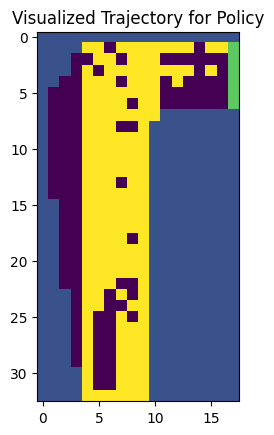

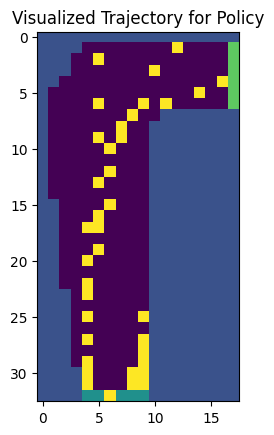

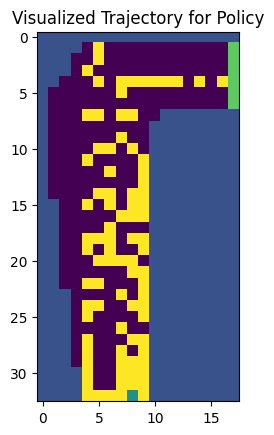

In [31]:
rolls = 3

for _ in range(rolls):
    visualize_trajectory(env3,pstar3)

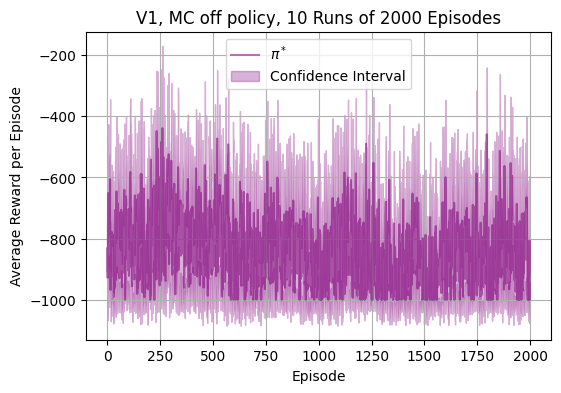

In [ ]:
# Figure 3 - V1 MC OP

fig, ax = plt.subplots(figsize=(6, 4))

Rs3arr = np.array(Rs3)

color = "#81007B8A"

avg = np.mean(Rs3arr,axis=0)
err = 1.96 * Rs3arr.std(axis=0) / np.sqrt(Rs3arr.shape[0])

ax.plot(avg,label="$\\pi^*$",color=color)
ax.fill_between(range(avg.shape[0]),avg-err,avg+err,alpha=0.3,color=color,label="Confidence Interval")

    
ax.set_ylabel("Average Reward per Episode")
ax.set_xlabel("Episode")
ax.set_title("V1, MC off policy, 10 Runs of 2000 Episodes")
ax.grid(True)
ax.legend()

V2

In [ ]:
env3 = Racetrack("v2")
# env.reset()
# env.render()
# print(env.state_space)
states = [tuple(s) for s in env4.state_space]
actions = [tuple(a) for a in env4.action_space]
# print(states)

policy_info = {s: {a: 1/len(actions) for a in actions} for s in states}
starter_policy = Policy(policy_info,np.random.default_rng(2025))
# print(policy_info)

runs = 3
episodes = 2000


Rs4 = []

for _ in tqdm(range(runs),desc="Runs",position=0):
    Q,pstar4,bpolicy,episode_lengths,rewards = run_MC_control_e_every_visit_off_policy(env4,states,actions,starter_policy,starter_policy,0.1,1,episodes=episodes)
    Rs4.append(rewards)
# env.render()



Runs:   0%|          | 0/3 [00:00<?, ?it/s]

MC:   0%|          | 0/2000 [00:00<?, ?it/s]

MC:   0%|          | 0/2000 [00:00<?, ?it/s]

MC:   0%|          | 0/2000 [00:00<?, ?it/s]

In [ ]:
# Test 4 - V2 MC OP

# env4 = Racetrack("v1")
# # env.reset()
# # env.render()
# # print(env.state_space)
# states = [tuple(s) for s in env4.state_space]
# actions = [tuple(a) for a in env4.action_space]
# print(states)


# policy_info = {s: {a: 1/len(actions) for a in actions} for s in states}
# starter_policy = Policy(policy_info,np.random.default_rng(seed))
# print(policy_info)

runs = 10
episodes = 2000

def do_one_run(seed):
    env4 = Racetrack("v2")
    states = [tuple(s) for s in env4.state_space]
    actions = [tuple(a) for a in env4.action_space]
    policy_info = {s: {a: 1/len(actions) for a in actions} for s in states}
    starter_policy = Policy(policy_info,np.random.default_rng(seed))
    Q,pstar4,bpolicy,episode_lengths,rewards = run_MC_control_e_every_visit_off_policy(env4,states,actions,starter_policy,starter_policy,0.1,1,episodes=episodes)

    return pstar4,rewards
    

# Rs3 = []
# for _ in tqdm(range(runs),desc="Runs",position=0):
#     Q,pstar3,bpolicy,episode_lengths,rewards = run_MC_control_e_every_visit_off_policy(env3,states,actions,starter_policy,starter_policy,0.1,1,episodes=episodes)
#     Rs3.append(rewards)
# env.render()

Results4 = Parallel(
    n_jobs=5,
    prefer="processes",
    batch_size=1
)(
    delayed(do_one_run)(2025 + i)
    for i in tqdm(range(runs), desc="Parallel")
)

pstar4 = Results4[-1][0]
Rs4 = [r[1] for r in Results4]


Parallel:   0%|          | 0/10 [00:00<?, ?it/s]

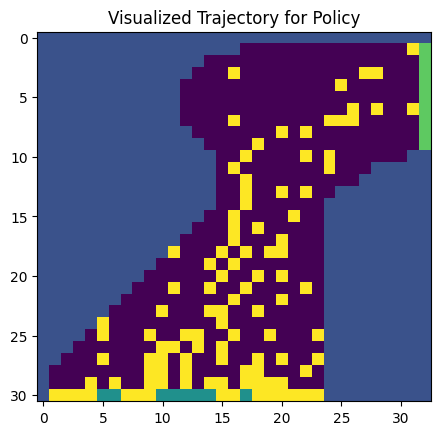

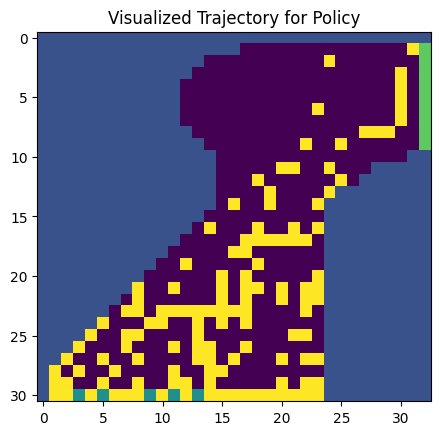

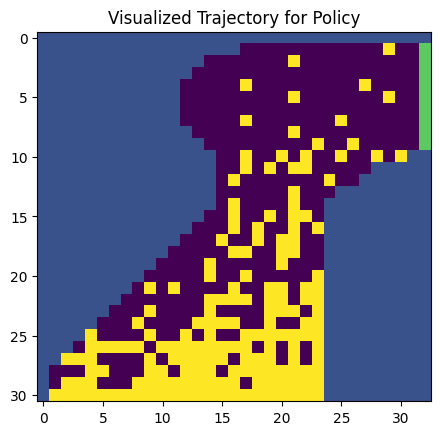

In [36]:
rolls = 3
env4 = Racetrack("v2")

for _ in range(rolls):
    visualize_trajectory(env4,pstar4)

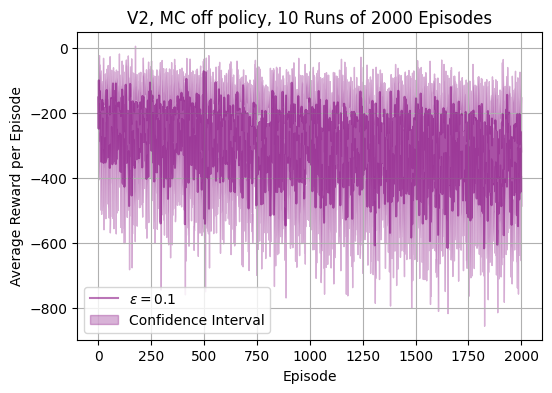

In [ ]:
# Figure 4 - V2 MC OP

fig, ax = plt.subplots(figsize=(6, 4))

Rs4arr = np.array(Rs4)

color = "#81007B8A"

avg = np.mean(Rs4arr,axis=0)
err = 1.96 * Rs4arr.std(axis=0) / np.sqrt(Rs4arr.shape[0])

ax.plot(avg,label="$\\epsilon=0.1$",color=color)
ax.fill_between(range(avg.shape[0]),avg-err,avg+err,alpha=0.3,color=color,label="Confidence Interval")
    
ax.set_ylabel("Average Reward per Episode")
ax.set_xlabel("Episode")
ax.set_title("V2, MC off policy, 10 Runs of 2000 Episodes")
ax.grid(True)
ax.legend()